# FAA Twitter Analysis for Safety Signals and Complaints

Team: Samantha Archie, Joel Atikemah, Lucas Huynh, Hetong Wang

This notebook will serve as the main working notebook for the project. We use tweets related to the FAA, air traffic control, staffing shortages, aviation safety, and related policy discussions to study whether social media can provide early signals of potential airline safety concerns and customer complaints.

### Table of contents

I. Loading in data  
II. First pass checks  
III. Cleaning the structured fields  
IV. Basic EDA on the structured columns  
V. Preprocessing the text column  
VI. Basic text analysis with spaCy  
VII. N-grams  
VIII. Co-occurrence analysis  
IX. TF-IDF representation  
X. Linear dimensionality reduction  
XI. Manifold learning  
XII. Clustering  
XIII. Topic modeling with LDA  

In [1]:
from pathlib import Path
from urllib.parse import urlparse
import html
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 220)
pd.set_option('display.max_columns', 40)

## I. Loading in data

We begin with the raw scraped file and take a first look at the columns that came back from the scrape.

In [2]:
# read in the data

data_path = Path('tweets_2025.csv')
df_raw = pd.read_csv(data_path)

print(f'rows: {len(df_raw):,}')
print(f'columns: {len(df_raw.columns)}')
print(sorted(df_raw.columns.tolist()))

rows: 4,372
columns: 16
['author.profilePicture', 'bookmarkCount', 'createdAt', 'id', 'isPinned', 'isQuote', 'isReply', 'lang', 'likeCount', 'quoteCount', 'replyCount', 'retweetCount', 'source', 'text', 'url', 'viewCount']


In [3]:
df_raw.head(3)

,id,url,text,createdAt,author.profilePicture,retweetCount,replyCount,likeCount,quoteCount,viewCount,bookmarkCount,source,lang,isReply,isQuote,isPinned
0,1994856060495015968,https://x.com/Fly_Nashville/status/1994856060495015968,UPDATE NOV. 29 1:45 P.M.| The Federal Aviation Administration (FAA) has lifted the ground delay program for Nashville International Airport® (BNA®) that was due to an air traffic control staffing shortage. Safe trave...,Sat Nov 29 19:48:42 +0000 2025,https://pbs.twimg.com/profile_images/1336766832431271940/fyVSbdl-_normal.jpg,1,0,8,1,12090,2,NaN,en,False,True,False
1,1990230659403551159,https://x.com/TimcastNews/status/1990230659403551159,"🚨 BREAKING: The FAA is ending its flight-cut mandates at 40 major airports, after controller staffing finally stabilized following the shutdown. \n\nAirlines can return to regular schedules on Monday morning, althoug...",Mon Nov 17 01:29:00 +0000 2025,https://pbs.twimg.com/profile_images/1952496567853658112/80xjOjwx_normal.jpg,5,4,82,0,6714,1,NaN,en,False,NaN,False
2,1994780036230959188,https://x.com/Fly_Nashville/status/1994780036230959188,UPDATE | The Federal Aviation Administration (FAA) has lifted the ground stop for incoming flights to Nashville International Airport® (BNA®) that was due to an air traffic control staffing shortage. Safe travels! #B...,Sat Nov 29 14:46:36 +0000 2025,https://pbs.twimg.com/profile_images/1336766832431271940/fyVSbdl-_normal.jpg,4,0,15,1,11812,0,NaN,en,False,True,False


## II. First pass checks

Before cleaning anything, it helps to look at missingness, sparsity, duplicates, and a few basic distributions in the raw file.

In [4]:
def summarize_columns(frame):
    rows = []
    for col in frame.columns:
        series = frame[col]
        row = {
            'column': col,
            'dtype': str(series.dtype),
            'missing_count': int(series.isna().sum()),
            'missing_pct': round(100 * series.isna().mean(), 2),
            'n_unique': int(series.nunique(dropna=True))
        }
        if pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(series):
            row['zero_pct'] = round(100 * (series == 0).mean(), 2)
        else:
            row['zero_pct'] = np.nan
        rows.append(row)
    return pd.DataFrame(rows).sort_values(['missing_pct', 'n_unique'], ascending=[False, False]).reset_index(drop=True)


raw_column_summary = summarize_columns(df_raw)
raw_column_summary

,column,dtype,missing_count,missing_pct,n_unique,zero_pct
0,source,float64,4372,100.00,0,0.00
1,isQuote,object,3993,91.33,1,NaN
2,id,int64,0,0.00,2344,0.00
3,url,object,0,0.00,2344,NaN
4,text,object,0,0.00,2333,NaN
5,createdAt,object,0,0.00,2330,NaN
6,author.profilePicture,object,0,0.00,1625,NaN
7,viewCount,int64,0,0.00,1406,0.41
8,likeCount,int64,0,0.00,239,40.44
9,retweetCount,int64,0,0.00,122,69.17


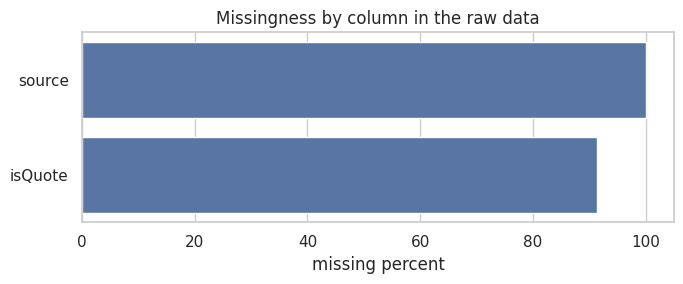

In [5]:
plt.figure(figsize=(7, 3))
missing_plot_df = raw_column_summary[raw_column_summary['missing_pct'] > 0]
sns.barplot(data=missing_plot_df, x='missing_pct', y='column')
plt.title('Missingness by column in the raw data')
plt.xlabel('missing percent')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [6]:
raw_duplicate_summary = pd.Series({
    'duplicate_ids': int(df_raw['id'].duplicated().sum()),
    'duplicate_urls': int(df_raw['url'].duplicated().sum()),
    'duplicate_texts': int(df_raw['text'].duplicated().sum()),
    'fully_duplicated_rows': int(df_raw.duplicated().sum())
})

raw_duplicate_summary

,0
duplicate_ids,2028
duplicate_urls,2028
duplicate_texts,2039
fully_duplicated_rows,1832


The duplicate counts are large enough that we should define a single working version of each tweet. For the rest of the notebook, we deduplicate by tweet ID and keep the row with the richest engagement snapshot.

In [7]:
raw_dates = pd.to_datetime(
    df_raw['createdAt'],
    format='%a %b %d %H:%M:%S %z %Y',
    utc=True
)

print('date range:')
print(raw_dates.min())
print(raw_dates.max())
print()
print('tweets by year:')
print(raw_dates.dt.year.value_counts().sort_index())
print()
print('language counts:')
print(df_raw['lang'].value_counts(dropna=False))

date range:
2023-01-11 18:24:40+00:00
2026-04-13 21:30:42+00:00

tweets by year:
createdAt
2023      42
2024     129
2025     778
2026    3423
Name: count, dtype: int64

language counts:
lang
en    4371
fr       1
Name: count, dtype: int64


## III. Cleaning the structured fields

Now we clean a few of the structured columns. In particular, we parse the timestamps, derive an author handle from the tweet URL, fill the boolean indicator columns, drop a few fields we probably will not use directly, and deduplicate by tweet ID.

In [8]:
def extract_author_handle(url):
    parts = [part for part in urlparse(str(url)).path.split('/') if part]
    return parts[0] if parts else np.nan


engagement_cols = ['retweetCount', 'replyCount', 'likeCount', 'quoteCount', 'viewCount', 'bookmarkCount']


df = df_raw.copy()
df['createdAt'] = pd.to_datetime(
    df['createdAt'],
    format='%a %b %d %H:%M:%S %z %Y',
    utc=True
)
df['author_handle'] = df['url'].map(extract_author_handle)

for col in ['isReply', 'isQuote', 'isPinned']:
    df[col] = df[col].where(df[col].notna(), False).astype(bool)

df = (df
      .sort_values(['id'] + engagement_cols)
      .drop_duplicates(subset='id', keep='last')
      .drop(columns=['url', 'author.profilePicture', 'source'])
      .copy())

df['date'] = df['createdAt'].dt.date
df['year'] = df['createdAt'].dt.year
df['year_month'] = df['createdAt'].dt.strftime('%Y-%m')
df['hour'] = df['createdAt'].dt.hour

cleaning_summary = pd.Series({
    'raw_rows': len(df_raw),
    'rows_after_dedup_by_id': len(df),
    'rows_removed_as_duplicate_ids': len(df_raw) - len(df),
    'date_min': df['createdAt'].min(),
    'date_max': df['createdAt'].max(),
    'unique_authors': df['author_handle'].nunique()
})

cleaning_summary

,0
raw_rows,4372
rows_after_dedup_by_id,2344
rows_removed_as_duplicate_ids,2028
date_min,2023-01-11 18:24:40+00:00
date_max,2026-04-13 21:30:42+00:00
unique_authors,1652


In [9]:
clean_column_summary = summarize_columns(df)
clean_column_summary

,column,dtype,missing_count,missing_pct,n_unique,zero_pct
0,id,int64,0,0.0,2344,0.00
1,text,object,0,0.0,2333,NaN
2,createdAt,"datetime64[ns, UTC]",0,0.0,2330,NaN
3,author_handle,object,0,0.0,1652,NaN
4,viewCount,int64,0,0.0,1300,0.55
5,date,object,0,0.0,424,NaN
6,likeCount,int64,0,0.0,230,40.74
7,retweetCount,int64,0,0.0,119,61.09
8,replyCount,int64,0,0.0,86,64.85
9,bookmarkCount,int64,0,0.0,74,76.88


## IV. Basic EDA on the structured columns

After deduplicating the tweets and dropping a few unused fields, we can look at who is posting, when the tweets appear, and how engagement is distributed across the sample.

In [10]:
print('tweets by year:')
print(df['year'].value_counts().sort_index())

tweets by year:
year
2023      42
2024     128
2025     745
2026    1429
Name: count, dtype: int64


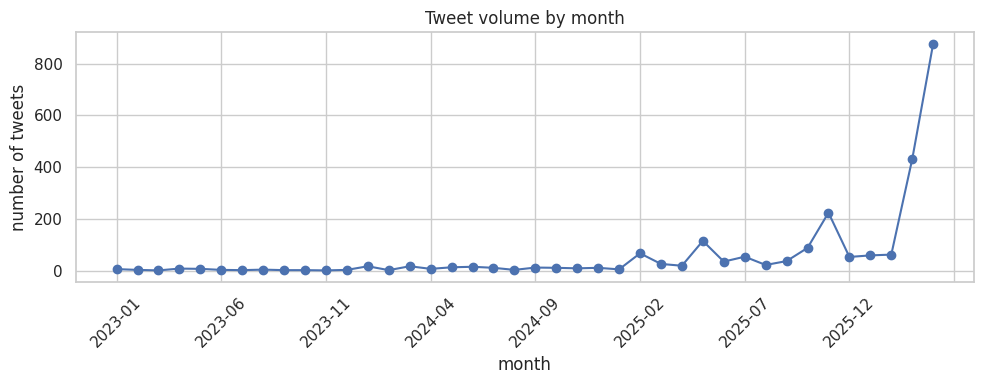

In [11]:
monthly_counts = df['year_month'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
monthly_counts.plot(marker='o')
plt.title('Tweet volume by month')
plt.xlabel('month')
plt.ylabel('number of tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
for col in ['lang', 'isReply', 'isQuote']:
    print(col)
    counts = df[col].value_counts(dropna=False)
    shares = (100 * df[col].value_counts(dropna=False, normalize=True)).round(2)
    display(pd.DataFrame({
        'count': counts,
        'share_pct': shares
    }))
    print()

lang


,count,share_pct
lang,,
en,2343,99.96
fr,1,0.04



isReply


,count,share_pct
isReply,,
False,1959,83.58
True,385,16.42



isQuote


,count,share_pct
isQuote,,
False,2172,92.66
True,172,7.34


In [13]:
top_authors = df['author_handle'].value_counts().head(15)

top_authors

,count
author_handle,
grok,47
FAASafetyBrief,34
AviationWeek,15
FAANews,15
business,14
NEWSMAX,13
PiQSuite,13
HypeAviation,13
SecDuffy,12


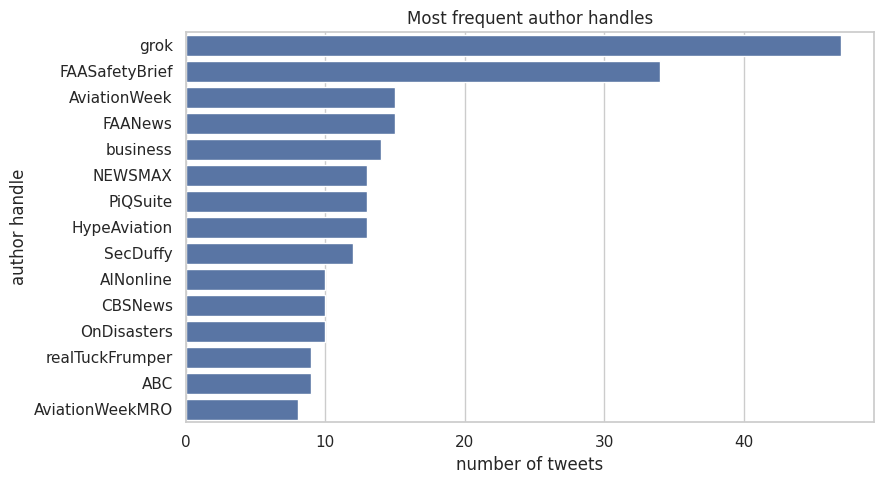

In [14]:
plt.figure(figsize=(9, 5))
sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title('Most frequent author handles')
plt.xlabel('number of tweets')
plt.ylabel('author handle')
plt.tight_layout()
plt.show()

In [15]:
reply_quote_summary = pd.DataFrame({
    'tweet_count': [
        len(df),
        int(df['isReply'].sum()),
        int(df['isQuote'].sum())
    ],
    'share_of_tweets': [
        1.0,
        df['isReply'].mean(),
        df['isQuote'].mean()
    ],
    'mean_views': [
        df['viewCount'].mean(),
        df.loc[df['isReply'], 'viewCount'].mean(),
        df.loc[df['isQuote'], 'viewCount'].mean()
    ],
    'median_views': [
        df['viewCount'].median(),
        df.loc[df['isReply'], 'viewCount'].median(),
        df.loc[df['isQuote'], 'viewCount'].median()
    ],
    'mean_likes': [
        df['likeCount'].mean(),
        df.loc[df['isReply'], 'likeCount'].mean(),
        df.loc[df['isQuote'], 'likeCount'].mean()
    ],
    'median_likes': [
        df['likeCount'].median(),
        df.loc[df['isReply'], 'likeCount'].median(),
        df.loc[df['isQuote'], 'likeCount'].median()
    ],
    'mean_retweets': [
        df['retweetCount'].mean(),
        df.loc[df['isReply'], 'retweetCount'].mean(),
        df.loc[df['isQuote'], 'retweetCount'].mean()
    ],
    'median_retweets': [
        df['retweetCount'].median(),
        df.loc[df['isReply'], 'retweetCount'].median(),
        df.loc[df['isQuote'], 'retweetCount'].median()
    ]
}, index=['all_tweets', 'replies', 'quotes']).round(2)

reply_quote_summary

,tweet_count,share_of_tweets,mean_views,median_views,mean_likes,median_likes,mean_retweets,median_retweets
all_tweets,2344,1.00,24784.70,348.0,129.31,1.0,23.35,0.0
replies,385,0.16,1244.98,80.0,28.08,1.0,3.49,0.0
quotes,172,0.07,229249.56,511.0,720.52,3.5,154.94,1.0


In [16]:
engagement_summary = pd.DataFrame({
    'mean': df[engagement_cols].mean(),
    'median': df[engagement_cols].median(),
    'std': df[engagement_cols].std(),
    'pct_zero': (100 * (df[engagement_cols] == 0).mean()),
    'max': df[engagement_cols].max()
}).round(2)

engagement_summary

,mean,median,std,pct_zero,max
retweetCount,23.35,0.0,428.34,61.09,20129
replyCount,11.55,0.0,217.67,64.85,9518
likeCount,129.31,1.0,1977.80,40.74,89943
quoteCount,2.33,0.0,55.66,83.15,2618
viewCount,24784.70,348.0,749232.13,0.55,36077130
bookmarkCount,7.04,0.0,114.16,76.88,4394


The mean-median gaps are fairly large for several engagement variables, which is a reminder that the distributions are highly skewed. That is one reason the later parts of the project will often rely on log transforms, medians, and other more robust summaries.

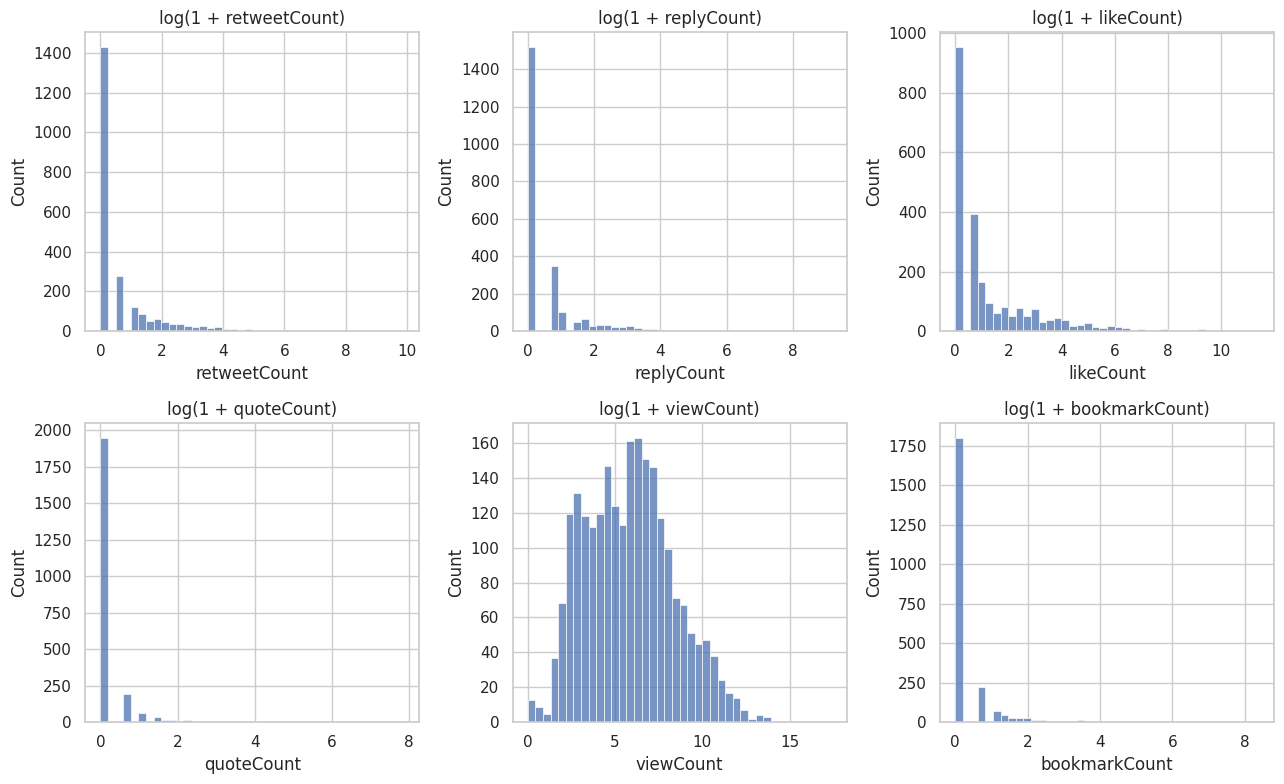

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()

for ax, col in zip(axes, engagement_cols):
    sns.histplot(np.log1p(df[col]), bins=40, ax=ax)
    ax.set_title(f'log(1 + {col})')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [18]:
# look at a few of the highest-engagement tweets

df.sort_values('viewCount', ascending=False)[[
    'createdAt', 'author_handle', 'viewCount', 'likeCount', 'retweetCount', 'replyCount', 'text'
]].head(10)

,createdAt,author_handle,viewCount,likeCount,retweetCount,replyCount,text
437,2025-02-18 01:12:17+00:00,SecDuffy,36077130,89943,20129,9518,"Mayor Pete failed for four years to address the air traffic controller shortage and upgrade our outdated, World War II-era air traffic control system. In less than four weeks, we have already begun the process and ar..."
3628,2026-04-10 14:31:09+00:00,SecDuffy,3197632,9528,1000,630,"🚨👀 Watch this…\n\nYOU can be the future of air traffic control\n\nIt’s not a GAME, its a CAREER \n\nApplications open April 17th at Midnight @FAANews https://t.co/JVpgCIeF58"
28,2026-03-23 08:10:36+00:00,juliamacfarlane,938463,6979,1809,503,"If FAA staffing shortages turn out to be a key aspect of this horrible tragedy, remember that @elonmusk\n and his “Doge” department fired hundreds of FAA staffers last year - including safety workers, and even tried ..."
1072,2025-11-06 02:42:34+00:00,AmericanAir,861448,2709,584,159,"Due to the ongoing government shutdown and nationwide air traffic control staffing shortages, the FAA has directed airlines to reduce flight schedules to maintain safe airspace operations starting Friday, Nov. 7.\n\n..."
1716,2025-02-17 21:46:27+00:00,EricLDaugh,728845,8498,1278,4135,NBC REPORTER ON PLANE CRASH: There has been talk about staff cuts at the FAA as a part of President Trump's effort to trim down the federal workforce. The FAA has been complaining for years that they are understaffed...
2535,2026-03-27 19:13:00+00:00,PiersUncensored,714584,2386,394,237,"""The pilots sacrificed themselves to save everybody.""\n\nCaptain Steeeve says the ""heroic"" Air Canada pilots involved in the LaGuardia plane crash ""could have veered left or right to avoid harm for them in the cockpi..."
2513,2026-03-27 21:37:05+00:00,FurkanGozukara,606497,10056,1804,209,Incredible heroism revealed. An aviation expert explains how the pilots in the LaGuardia crash intentionally took the impact head on. They refused to veer away to prevent the fuel filled wings from hitting the truck ...
2726,2026-03-26 22:24:12+00:00,flightradar24,526913,1275,153,27,The FAA says its investigation of the incident involving United flight 589 and a US Army Black Hawk will also include “whether a new measure to suspend the use of visual separation between airplanes and helicopters w...
2687,2026-01-28 09:35:45+00:00,Rainmaker1973,494404,2076,112,20,"These are medium-intensity red aviation obstruction lights, called L-864, used to mark tall structures for aircraft safety. \n\nThey flash 20–40 times per minute, meet FAA/ICAO standards, and offer infrared visibilit..."
2665,2026-01-30 20:02:07+00:00,FAANews,338263,343,25,5,"Laser strikes on aircraft are a serious threat to aviation safety, and pointing a laser at an aircraft is a federal crime. Know the safety risks and penalties, report strikes to the FAA and law enforcement and help u..."


## V. Preprocessing the text column

For the text, we keep two versions:

- `text_clean`: a lightly normalized version of the original tweet text
- `text_lemma`: a lemmatized version that should be convenient for later n-grams, topic modeling, dimensionality reduction, and clustering

The basic cleaning below removes URLs and mentions, keeps hashtag words, lowercases, normalizes whitespace, and preserves apostrophes so negation is not lost too early.

In [19]:
url_pattern = re.compile(r'https?://\S+|www\.\S+')
mention_pattern = re.compile(r'@\w+')
hashtag_pattern = re.compile(r'#(\w+)')
extra_space_pattern = re.compile(r'\s+')
non_text_pattern = re.compile(r"[^a-z0-9'\s]")


def basic_clean(text):
    text = html.unescape(str(text))
    text = text.replace('\n', ' ')
    text = text.replace('’', "'")
    text = url_pattern.sub(' ', text)
    text = hashtag_pattern.sub(r' \1 ', text)
    text = mention_pattern.sub(' ', text)
    text = text.lower()
    text = non_text_pattern.sub(' ', text)
    text = extra_space_pattern.sub(' ', text).strip()
    return text

In [20]:
df['text_clean'] = df['text'].map(basic_clean)
df[['text', 'text_clean']].head(8)

,text,text_clean
4364,Flight cancellations and delays pile up after an FAA safety system outage\n\nhttps://t.co/N4ol3GxEEC,flight cancellations and delays pile up after an faa safety system outage
4302,"Delays and cancellations among flights across the U.S. were minimal Thursday, a day after a system that offers safety information to pilots failed, grounding U.S. air traffic and leading to thousands of stranded trav...",delays and cancellations among flights across the u s were minimal thursday a day after a system that offers safety information to pilots failed grounding u s air traffic and leading to thousands of stranded travelers
4309,"The FAA continues its investigation to determine who and what is responsible for the corrupted file that caused a flight safety system outage Wednesday. Meanwhile, there were more delays Thursday and travelers are fe...",the faa continues its investigation to determine who and what is responsible for the corrupted file that caused a flight safety system outage wednesday meanwhile there were more delays thursday and travelers are fed up
4246,"Delays and cancellations among flights across the United States were minimal on Thursday, a day after a system that offers safety information to pilots failed, grounding U.S. air traffic and leading to thousands of s...",delays and cancellations among flights across the united states were minimal on thursday a day after a system that offers safety information to pilots failed grounding u s air traffic and leading to thousands of stra...
3045,"""The hope of ATC [air traffic control] reform has been kept alive from administration to administration by tenacious advocates like the Reason Foundation’s Robert Poole, who care about making America a better place,""...",the hope of atc air traffic control reform has been kept alive from administration to administration by tenacious advocates like the reason foundation's robert poole who care about making america a better place write...
4269,"The🐉dragons of doubt🐉can also wake up when weather or mechanical delays keep you on the ground. When those days arrive, a mentor’s encouragement and support can make all the difference in sending the 🐉dragons of doub...",the dragons of doubt can also wake up when weather or mechanical delays keep you on the ground when those days arrive a mentor's encouragement and support can make all the difference in sending the dragons of doubt t...
4313,"Buttigieg, FAA pressed for details on airline safety after Chinese spy mission delays flights https://t.co/c6sQ1Dr4Gq",buttigieg faa pressed for details on airline safety after chinese spy mission delays flights
4008,"@NickTagliaferro The Navy, Border Control and Air Traffic Control are all established in federal legislation… which he would also be sunsetting.\n\nhttps://t.co/dZEwjpHLm1",the navy border control and air traffic control are all established in federal legislation which he would also be sunsetting


The preprocessing demos in class use spaCy lemmatization, so we follow that same general pattern here.

In [21]:
# lemmatize the cleaned text

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])


def lemmatize_texts(texts, batch_size=64):
    docs = []
    for doc in tqdm(nlp.pipe(texts, batch_size=batch_size), total=len(texts)):
        tokens = [token.lemma_ for token in doc if not token.is_space and not token.is_punct]
        docs.append(' '.join(tokens))
    return docs


df['text_lemma'] = lemmatize_texts(df['text_clean'].tolist())
df['n_tokens_clean'] = df['text_clean'].str.split().str.len()
df['n_tokens_lemma'] = df['text_lemma'].str.split().str.len()

  0%|          | 0/2344 [00:00<?, ?it/s]

In [22]:
df[['text', 'text_clean', 'text_lemma']].sample(5, random_state=0)

,text,text_clean,text_lemma
3472,"Let me get this straight. The people of France have shut down air traffic control, trash pickup and are protesting en masse for pension reform and the US can't get it together to do the same for gun reform when our b...",let me get this straight the people of france have shut down air traffic control trash pickup and are protesting en masse for pension reform and the us can't get it together to do the same for gun reform when our bab...,let I get this straight the people of france have shut down air traffic control trash pickup and be protest en masse for pension reform and the us can not get it together to do the same for gun reform when our baby b...
2956,Federal Review Finds FAA Lacks Staff for United Airlines Maintenance Checks✈️\n\nA new federal audit has found that oversight of United Airlines (UA) by the Federal Aviation Administration (FAA) has been limited by s...,federal review finds faa lacks staff for united airlines maintenance checks a new federal audit has found that oversight of united airlines ua by the federal aviation administration faa has been limited by staffing s...,federal review find faa lack staff for united airlines maintenance check a new federal audit have find that oversight of united airlines ua by the federal aviation administration faa have be limit by staff shortage a...
4132,"American Aviation Act"" (H.R. 3935), was signed into law on May 16, 2024. This bipartisan legislation authorizes a total of $105.5 billion in funding. $66 Billion for air traffic control",american aviation act h r 3935 was signed into law on may 16 2024 this bipartisan legislation authorizes a total of 105 5 billion in funding 66 billion for air traffic control,american aviation act h r 3935 be sign into law on may 16 2024 this bipartisan legislation authorize a total of 105 5 billion in fund 66 billion for air traffic control
1060,"Flight delays linked to the ongoing federal government shutdown continue, with this past weekend marking the worst for air traffic control staffing shortages since the shutdown began. https://t.co/mKS3S6AUbg",flight delays linked to the ongoing federal government shutdown continue with this past weekend marking the worst for air traffic control staffing shortages since the shutdown began,flight delay link to the ongoing federal government shutdown continue with this past weekend mark the bad for air traffic control staffing shortage since the shutdown begin
360,Good sharing ! Exceptional approach to improve customer safety as well as to help shorten FAA process. No other comp. does this like Joby.,good sharing exceptional approach to improve customer safety as well as to help shorten faa process no other comp does this like joby,good sharing exceptional approach to improve customer safety as well as to help shorten faa process no other comp do this like joby


In [23]:
df[['n_tokens_clean', 'n_tokens_lemma']].describe().round(2)

,n_tokens_clean,n_tokens_lemma
count,2344.00,2344.00
mean,35.24,35.78
std,45.65,46.41
min,1.00,1.00
25%,16.00,16.00
50%,29.00,29.00
75%,40.00,41.00
max,1289.00,1315.00


## VI. Basic text analysis with spaCy

The spaCy demos in class start by inspecting how the parser sees an individual document, so we do the same here with one tweet. After that, we move to simple corpus-level summaries such as parts of speech and named entities.

In [24]:
nlp_full = spacy.load('en_core_web_sm')

example_text = df.sort_values('viewCount', ascending=False)['text'].iloc[0]
parsed_example = nlp_full(example_text)

pd.DataFrame([{
    'token': token.text,
    'lemma': token.lemma_,
    'pos': token.pos_,
    'entity_type': token.ent_type_
} for token in parsed_example]).head(30)

,token,lemma,pos,entity_type
0,Mayor,Mayor,PROPN,
1,Pete,Pete,PROPN,PERSON
2,failed,fail,VERB,
3,for,for,ADP,
4,four,four,NUM,DATE
5,years,year,NOUN,DATE
6,to,to,PART,
7,address,address,VERB,
8,the,the,DET,
9,air,air,NOUN,


In [25]:
from collections import Counter

pos_counts = Counter()
entity_counts = Counter()
entity_labels_to_keep = {'ORG', 'GPE', 'PERSON', 'FAC'}

for doc in tqdm(nlp_full.pipe(df['text'].tolist(), batch_size=64), total=len(df)):
    for token in doc:
        if not token.is_space:
            pos_counts[token.pos_] += 1
    for ent in doc.ents:
        if ent.label_ in entity_labels_to_keep and len(ent.text.strip()) > 2:
            entity_counts[(ent.text, ent.label_)] += 1

top_pos = pd.DataFrame(pos_counts.most_common(15), columns=['part_of_speech', 'count'])
top_pos

  0%|          | 0/2344 [00:00<?, ?it/s]

,part_of_speech,count
0,NOUN,24245
1,PROPN,14451
2,PUNCT,10558
3,VERB,10193
4,ADP,8601
5,DET,6153
6,ADJ,5507
7,PRON,3724
8,AUX,3608
9,ADV,2543


In [26]:
top_entities = pd.DataFrame([
    {'entity': text, 'label': label, 'count': count}
    for (text, label), count in entity_counts.most_common(20)
])
top_entities

,entity,label,count
0,FAA,ORG,1039
1,LaGuardia,ORG,215
2,U.S.,GPE,131
3,Air Canada,ORG,129
4,LaGuardia Airport,FAC,98
5,Boeing,ORG,86
6,The Federal Aviation Administration,ORG,62
7,Congress,ORG,60
8,ATC,ORG,53
9,Trump,PERSON,52


## VII. N-grams

Next we turn to simple word-based n-grams. This is a straightforward way to see what topics and short phrases dominate the tweet corpus before we move to more structured text models.

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(texts, ngram_range=(1, 1), min_df=5, top_n=20):
    vectorizer = CountVectorizer(stop_words='english', ngram_range=ngram_range, min_df=min_df)
    counts = vectorizer.fit_transform(texts)
    frequencies = counts.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()
    top_idx = np.argsort(frequencies)[::-1][:top_n]
    return pd.DataFrame({
        'ngram': vocab[top_idx],
        'count': frequencies[top_idx]
    })


In [28]:
top_unigrams = get_top_ngrams(df['text_clean'], ngram_range=(1, 1), min_df=5, top_n=20)
top_unigrams

,ngram,count
0,air,1824
1,traffic,1532
2,control,1237
3,faa,1208
4,safety,727
5,aviation,561
6,staffing,383
7,airport,380
8,laguardia,379
9,flight,329


In [29]:
top_bigrams = get_top_ngrams(df['text_clean'], ngram_range=(2, 2), min_df=5, top_n=20)
top_bigrams

,ngram,count
0,air traffic,1484
1,traffic control,1157
2,air canada,191
3,federal aviation,163
4,aviation administration,162
5,traffic controllers,155
6,control staffing,142
7,traffic controller,131
8,aviation safety,129
9,laguardia airport,125


In [30]:
top_trigrams = get_top_ngrams(df['text_clean'], ngram_range=(3, 3), min_df=5, top_n=20)
top_trigrams

,ngram,count
0,air traffic control,1151
1,federal aviation administration,162
2,air traffic controllers,154
3,traffic control staffing,142
4,air traffic controller,131
5,traffic control reform,89
6,aviation administration faa,86
7,understaffed air traffic,80
8,traffic control tower,66
9,traffic controller shortage,60


## VIII. Co-occurrence analysis

Following the co-occurrence demo, we now define a small set of keywords tied to the themes we expect to matter in this project. The goal here is not to be exhaustive, but to get a first look at which concerns appear together in the same tweets.

In [31]:
keyword_groups = {
    'faa': ['faa', 'federal aviation administration'],
    'air_traffic_control': ['air traffic control', 'atc'],
    'staffing': ['staffing', 'understaffed', 'shortage', 'shortages'],
    'safety': ['safety', 'oversight'],
    'laguardia': ['laguardia'],
    'boeing': ['boeing'],
    'delays': ['delay', 'delays'],
    'gamers': ['gamers', 'gamer'],
    'reform': ['reform', 'legislation']
}

docs = []
for text in df['text_clean']:
    labels = []
    for label, terms in keyword_groups.items():
        if any(term in text for term in terms):
            labels.append(label)
    docs.append(labels)

pd.DataFrame({
    'text_clean': df['text_clean'].head(10),
    'keyword_labels': docs[:10]
})

,text_clean,keyword_labels
4364,flight cancellations and delays pile up after an faa safety system outage,"[faa, safety, delays]"
4302,delays and cancellations among flights across the u s were minimal thursday a day after a system that offers safety information to pilots failed grounding u s air traffic and leading to thousands of stranded travelers,"[safety, delays]"
4309,the faa continues its investigation to determine who and what is responsible for the corrupted file that caused a flight safety system outage wednesday meanwhile there were more delays thursday and travelers are fed up,"[faa, safety, delays]"
4246,delays and cancellations among flights across the united states were minimal on thursday a day after a system that offers safety information to pilots failed grounding u s air traffic and leading to thousands of stra...,"[safety, delays]"
3045,the hope of atc air traffic control reform has been kept alive from administration to administration by tenacious advocates like the reason foundation's robert poole who care about making america a better place write...,"[air_traffic_control, reform]"
4269,the dragons of doubt can also wake up when weather or mechanical delays keep you on the ground when those days arrive a mentor's encouragement and support can make all the difference in sending the dragons of doubt t...,[delays]
4313,buttigieg faa pressed for details on airline safety after chinese spy mission delays flights,"[faa, safety, delays]"
4008,the navy border control and air traffic control are all established in federal legislation which he would also be sunsetting,"[air_traffic_control, reform]"
4229,the aviation industry is facing backlash after recent technical errors caused delays and potential safety issues for many flyers on the foxnewsrundown president mike boyd explains how these recent errors could be pre...,"[faa, safety, delays]"
3472,let me get this straight the people of france have shut down air traffic control trash pickup and are protesting en masse for pension reform and the us can't get it together to do the same for gun reform when our bab...,"[air_traffic_control, reform]"


In [32]:
keyword_labels = list(keyword_groups.keys())

marginal_probabilities = []
for label in keyword_labels:
    probability = sum(label in doc for doc in docs) / len(docs)
    marginal_probabilities.append({'keyword': label, 'probability': probability})

marginal_probabilities = pd.DataFrame(marginal_probabilities).sort_values('probability', ascending=False)
marginal_probabilities

,keyword,probability
1,air_traffic_control,0.576792
0,faa,0.453925
3,safety,0.297355
2,staffing,0.288396
4,laguardia,0.148464
6,delays,0.139932
8,reform,0.114334
7,gamers,0.066126
5,boeing,0.039676


In [33]:
co_occurrence_rows = []
for i, keyword_1 in enumerate(keyword_labels):
    for keyword_2 in keyword_labels[i+1:]:
        probability = sum(keyword_1 in doc and keyword_2 in doc for doc in docs) / len(docs)
        co_occurrence_rows.append({
            'keyword_1': keyword_1,
            'keyword_2': keyword_2,
            'co_occurrence_probability': probability
        })

co_occurrence_df = pd.DataFrame(co_occurrence_rows).sort_values('co_occurrence_probability', ascending=False)
co_occurrence_df.head(15)

,keyword_1,keyword_2,co_occurrence_probability
2,faa,safety,0.249573
8,air_traffic_control,staffing,0.238908
0,faa,air_traffic_control,0.174488
1,faa,staffing,0.138225
14,air_traffic_control,reform,0.105375
5,faa,delays,0.090870
12,air_traffic_control,delays,0.076365
18,staffing,delays,0.072526
23,safety,delays,0.069113
9,air_traffic_control,safety,0.069113


In [34]:
marginal_lookup = dict(zip(marginal_probabilities['keyword'], marginal_probabilities['probability']))

pmi_rows = []
for _, row in co_occurrence_df.iterrows():
    if row['co_occurrence_probability'] > 0:
        ratio = row['co_occurrence_probability'] / (marginal_lookup[row['keyword_1']] * marginal_lookup[row['keyword_2']])
        pmi_rows.append({
            'keyword_1': row['keyword_1'],
            'keyword_2': row['keyword_2'],
            'co_occurrence_probability': row['co_occurrence_probability'],
            'pmi': np.log(ratio)
        })

pmi_df = pd.DataFrame(pmi_rows).sort_values('pmi', ascending=False)
pmi_df.head(15)

,keyword_1,keyword_2,co_occurrence_probability,pmi
14,safety,boeing,0.035410,1.099070
13,faa,boeing,0.037543,0.734561
0,faa,safety,0.249573,0.614650
7,staffing,delays,0.072526,0.586206
8,safety,delays,0.069113,0.507411
10,air_traffic_control,gamers,0.062713,0.497281
4,air_traffic_control,reform,0.105375,0.468675
15,staffing,gamers,0.029437,0.434102
1,air_traffic_control,staffing,0.238908,0.362018
5,faa,delays,0.090870,0.358102


## IX. TF-IDF representation

To move toward dimensionality reduction, we first convert the tweet text into a TF-IDF matrix. This gives each tweet a high-dimensional numerical representation where words that are common across nearly all tweets get down-weighted.

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

vocab_size = 3000
tfidf_vectorizer = TfidfVectorizer(max_df=0.8,
                                 min_df=5,
                                 stop_words='english',
                                 max_features=vocab_size)

tfidf = tfidf_vectorizer.fit_transform(df['text_lemma'])
vocab = tfidf_vectorizer.get_feature_names_out()

print('TF-IDF matrix shape:')
print(tfidf.shape)
print()
print('matrix type:')
print(type(tfidf))

TF-IDF matrix shape:
(2344, 1506)

matrix type:
<class 'scipy.sparse._csr.csr_matrix'>


## X. Linear dimensionality reduction

For text, we do not usually apply PCA directly to the raw TF-IDF matrix. The reason is that TF-IDF matrices are sparse, while PCA centers every column and therefore tends to destroy sparsity and become more memory-intensive. `TruncatedSVD` plays the same role as a linear low-dimensional baseline for sparse text data, so it is the standard choice here.

In [36]:
from sklearn.decomposition import TruncatedSVD

svd_n_components = 50
svd = TruncatedSVD(n_components=svd_n_components, random_state=0)
svd_embeddings = svd.fit_transform(tfidf)
explained_variance = svd.explained_variance_ratio_
cumulative_explained_variance = explained_variance.cumsum()

print('SVD embedding shape:')
print(svd_embeddings.shape)

SVD embedding shape:
(2344, 50)


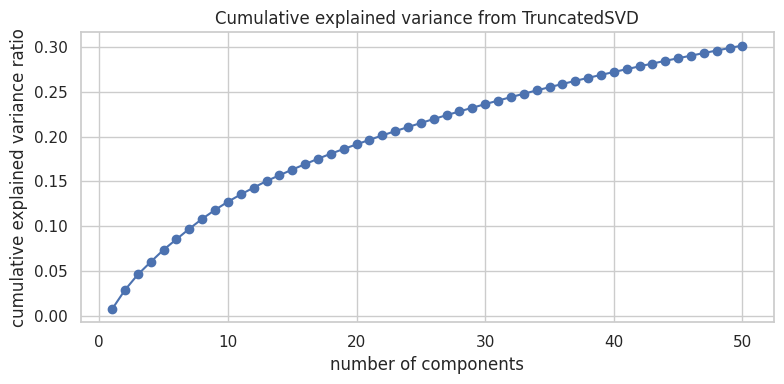

In [37]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, svd_n_components + 1), cumulative_explained_variance, marker='o')
plt.title('Cumulative explained variance from TruncatedSVD')
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance ratio')
plt.tight_layout()
plt.show()

As is common for text data, no small number of linear components explains most of the variation. Even so, the first several components still provide a useful lower-dimensional summary for visualization and clustering.

In [38]:
def get_top_component_terms(model, vocab, component_idx, top_n=10):
    weights = model.components_[component_idx]
    top_idx = np.argsort(weights)[::-1][:top_n]
    return pd.DataFrame({
        'term': vocab[top_idx],
        'weight': weights[top_idx]
    })

pd.concat([
    get_top_component_terms(svd, vocab, component_idx=i, top_n=8).assign(component=f'component_{i+1}')
    for i in range(4)
], ignore_index=True)

,term,weight,component
0,air,0.401911,component_1
1,traffic,0.401437,component_1
2,control,0.365639,component_1
3,faa,0.202388,component_1
4,shortage,0.186418,component_1
5,controller,0.161185,component_1
6,airport,0.150360,component_1
7,staffing,0.140504,component_1
8,laguardia,0.381536,component_2
9,crash,0.295401,component_2


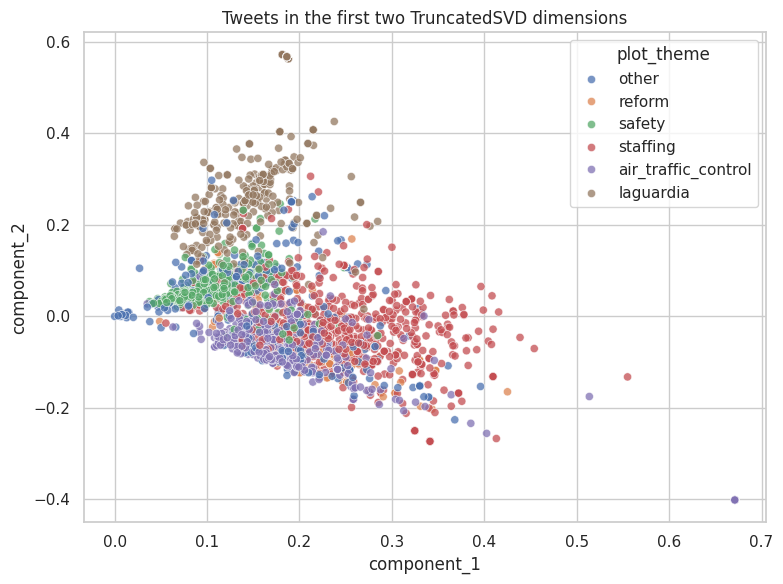

In [39]:
theme_keywords = {
    'staffing': ['staffing', 'understaffed', 'shortage', 'shortages'],
    'delays': ['delay', 'delays'],
    'laguardia': ['laguardia'],
    'boeing': ['boeing'],
    'reform': ['reform', 'legislation'],
    'gamers': ['gamers', 'gamer'],
    'safety': ['safety', 'oversight'],
    'air_traffic_control': ['air traffic control', 'atc'],
    'faa': ['faa', 'federal aviation administration']
}

def assign_primary_theme(text):
    for label, terms in theme_keywords.items():
        if any(term in text for term in terms):
            return label
    return 'other'

df['primary_theme'] = df['text_clean'].map(assign_primary_theme)
plot_themes = df['primary_theme'].value_counts().head(5).index
df['plot_theme'] = df['primary_theme'].where(df['primary_theme'].isin(plot_themes), 'other')

plot_df = pd.DataFrame({
    'component_1': svd_embeddings[:, 0],
    'component_2': svd_embeddings[:, 1],
    'plot_theme': df['plot_theme']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='component_1', y='component_2', hue='plot_theme', alpha=0.75, s=35)
plt.title('Tweets in the first two TruncatedSVD dimensions')
plt.tight_layout()
plt.show()

The first two linear dimensions already separate some recurring themes, although the clusters are not completely clean. That is a good sign that there is meaningful structure in the text, but also a reminder that a purely linear view may miss local relationships.

## XI. Manifold learning

We now apply nonlinear manifold methods to a lower-dimensional dense representation of the tweets. We first reduce the TF-IDF matrix with `TruncatedSVD`, then run manifold methods on a random sample of tweets so that the notebook stays reasonably fast to rerun.

In [40]:
from sklearn.manifold import Isomap, MDS, TSNE

manifold_sample_size = min(600, len(df))
sample_positions = np.random.default_rng(0).choice(len(df), size=manifold_sample_size, replace=False)
manifold_input = svd_embeddings[sample_positions, :25]
manifold_theme = df.iloc[sample_positions]['plot_theme'].reset_index(drop=True)

print('manifold input shape:')
print(manifold_input.shape)
print()
print('theme counts in the manifold sample:')
print(manifold_theme.value_counts())

manifold input shape:
(600, 25)

theme counts in the manifold sample:
plot_theme
staffing               152
air_traffic_control    111
other                  103
safety                  90
laguardia               88
reform                  56
Name: count, dtype: int64


In [41]:
def plot_embedding(embedding, title, hue_values):
    plot_frame = pd.DataFrame({
        'x': embedding[:, 0],
        'y': embedding[:, 1],
        'plot_theme': hue_values
    })
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=plot_frame, x='x', y='y', hue='plot_theme', alpha=0.8, s=35)
    plt.title(title)
    plt.tight_layout()
    plt.show()

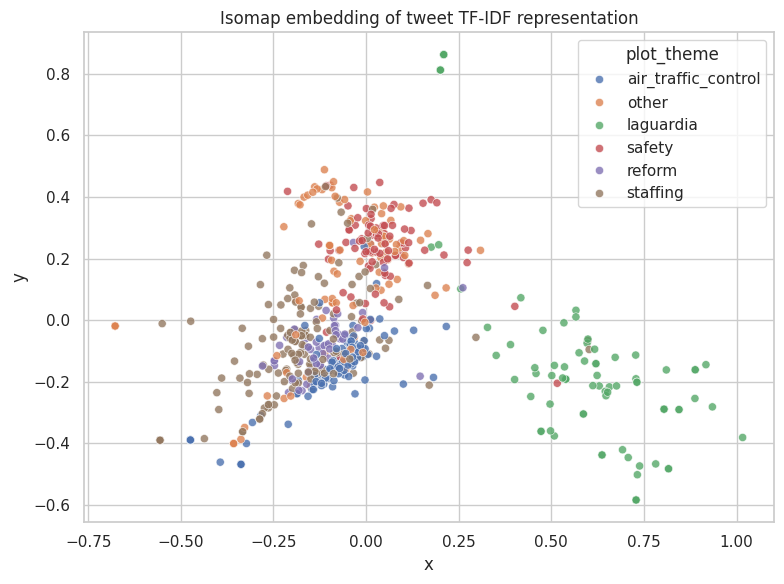

In [42]:
isomap = Isomap(n_neighbors=15, n_components=2)
isomap_embedding = isomap.fit_transform(manifold_input)
plot_embedding(isomap_embedding, 'Isomap embedding of tweet TF-IDF representation', manifold_theme)

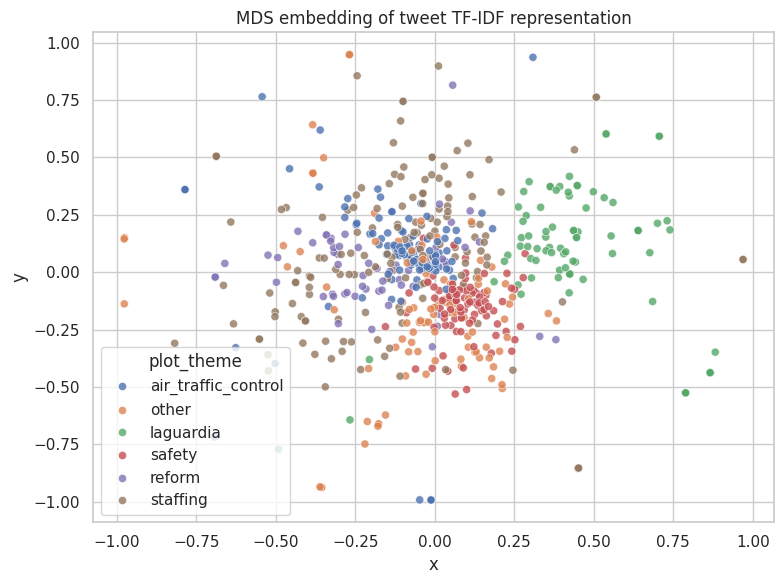

In [43]:
mds = MDS(n_components=2, random_state=0, n_init=1, max_iter=300)
mds_embedding = mds.fit_transform(manifold_input)
plot_embedding(mds_embedding, 'MDS embedding of tweet TF-IDF representation', manifold_theme)

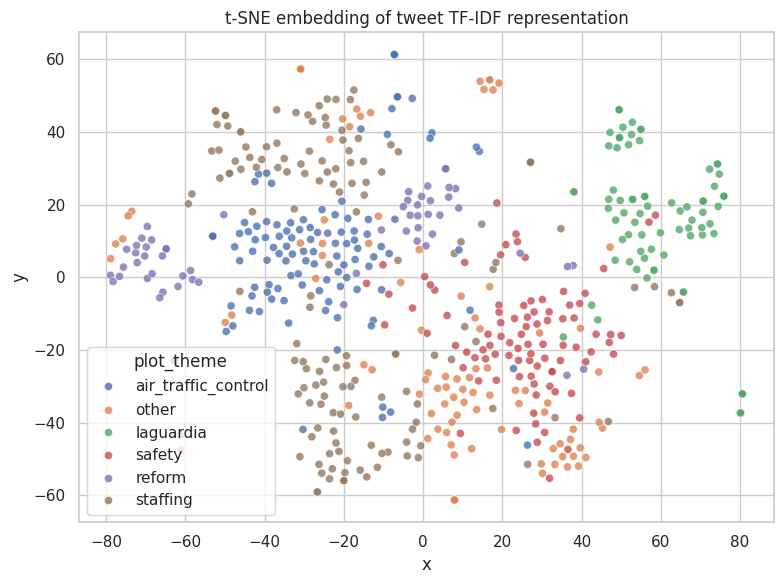

In [44]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=0, max_iter=1000)
tsne_embedding = tsne.fit_transform(manifold_input)
plot_embedding(tsne_embedding, 't-SNE embedding of tweet TF-IDF representation', manifold_theme)

The UMAP code is left below as a commented block because it was slow or unstable in the local VS Code environment. If needed, it can be run separately in Google Colab or another environment where `umap-learn` is configured cleanly.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


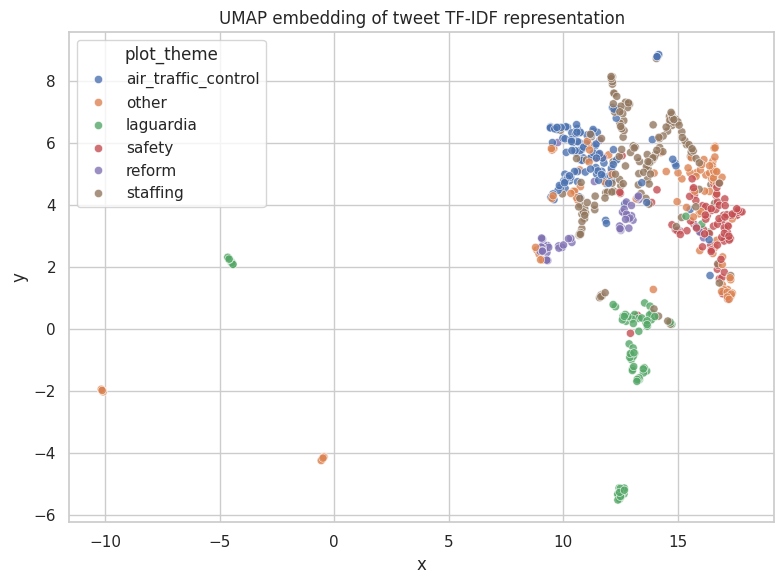

In [45]:
from umap import UMAP

umap = UMAP(n_components=2, n_neighbors=15, min_dist=0.2, random_state=0)
umap_embedding = umap.fit_transform(manifold_input)
plot_embedding(umap_embedding, 'UMAP embedding of tweet TF-IDF representation', manifold_theme)

Across the manifold methods, Isomap provides a readable global structure, MDS is more diffuse, and t-SNE tends to give the clearest local grouping. In practice, these plots are most useful as exploratory visualizations rather than as direct evidence of hard cluster boundaries.

## XII. Clustering

After building linear and nonlinear low-dimensional representations, we can now try clustering the tweet corpus. We start with `k`-means on the lower-dimensional SVD representation, then look at `DBSCAN` as a density-based alternative.

In [46]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from hdbscan import HDBSCAN

In [47]:
cluster_input = svd_embeddings[:, :25]
k_values = list(range(2, 11))
kmeans_model_fits = {}
kmeans_diagnostics = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=20)
    cluster_labels = kmeans.fit_predict(cluster_input)
    kmeans_model_fits[k] = (kmeans, cluster_labels)
    kmeans_diagnostics.append({
        'k': k,
        'rss': kmeans.inertia_,
        'inertia': kmeans.inertia_,
        'silhouette_score': silhouette_score(cluster_input, cluster_labels),
        'ch_index': calinski_harabasz_score(cluster_input, cluster_labels)
    })

kmeans_diagnostics = pd.DataFrame(kmeans_diagnostics)
kmeans_diagnostics

,k,rss,inertia,silhouette_score,ch_index
0,2,446.754817,446.754817,0.215969,205.367096
1,3,417.693852,417.693852,0.099123,191.216961
2,4,392.434884,392.434884,0.084906,185.830204
3,5,366.614166,366.614166,0.124546,190.308530
4,6,345.749576,345.749576,0.120696,189.583058
5,7,325.662677,325.662677,0.142608,191.683111
6,8,305.610066,305.610066,0.146079,196.902099
7,9,285.474691,285.474691,0.156761,204.949266
8,10,270.387018,270.387018,0.169628,206.731161


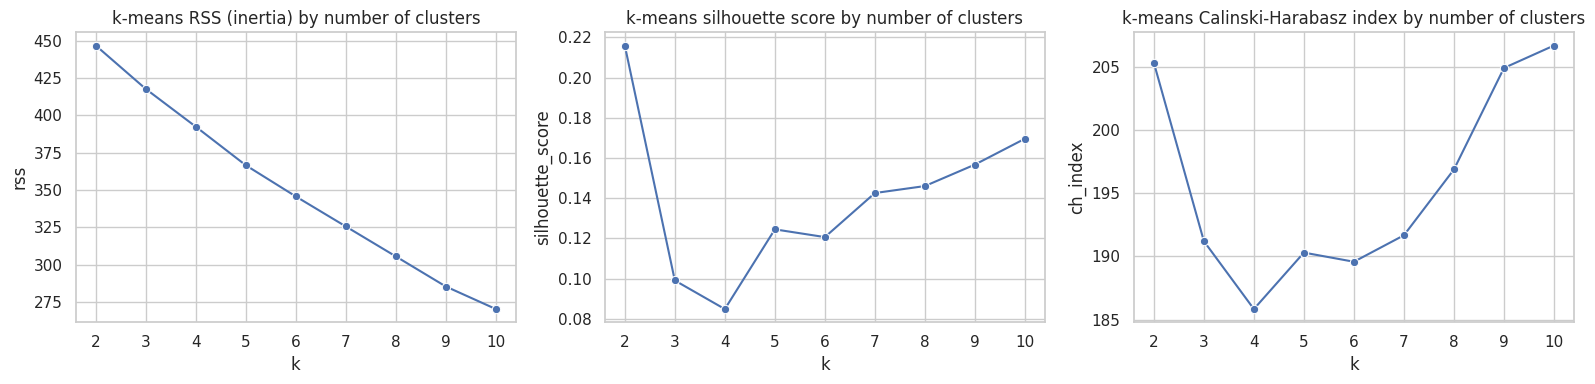

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.lineplot(data=kmeans_diagnostics, x='k', y='rss', marker='o', ax=axes[0])
axes[0].set_title('k-means RSS (inertia) by number of clusters')

sns.lineplot(data=kmeans_diagnostics, x='k', y='silhouette_score', marker='o', ax=axes[1])
axes[1].set_title('k-means silhouette score by number of clusters')

sns.lineplot(data=kmeans_diagnostics, x='k', y='ch_index', marker='o', ax=axes[2])
axes[2].set_title('k-means Calinski-Harabasz index by number of clusters')

plt.tight_layout()
plt.show()

In `sklearn`, the `inertia` attribute is the within-cluster residual sum of squares, so the RSS and inertia columns are the same quantity. We use these cluster-quality measures only as rough guides, since interpretability still matters for choosing a useful `k`. Here we will use `k = 5` as a slightly simpler and more interpretable partition of the tweet corpus.

In [49]:
chosen_k = 5
kmeans, kmeans_labels = kmeans_model_fits[chosen_k]
df['kmeans_cluster'] = kmeans_labels

print(f'chosen k: {chosen_k}')
df['kmeans_cluster'].value_counts().sort_index()

chosen k: 5


,count
kmeans_cluster,
0,1142
1,842
2,36
3,297
4,27


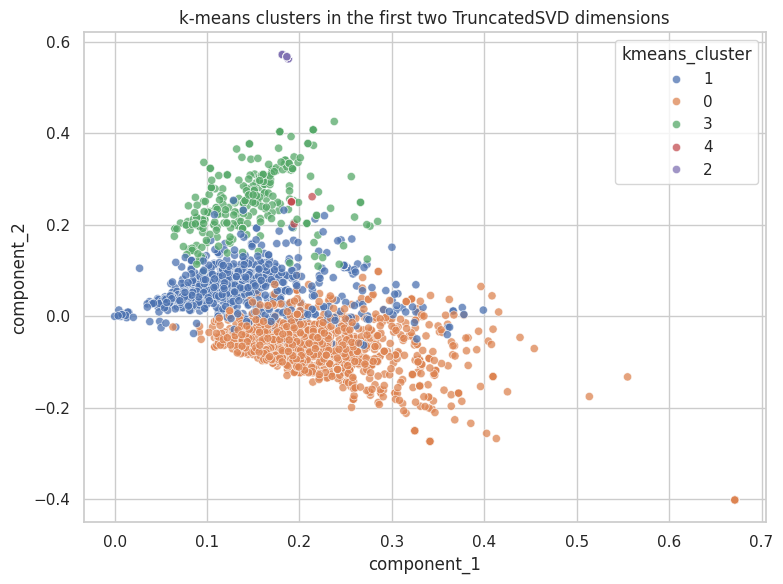

In [50]:
cluster_plot_df = pd.DataFrame({
    'component_1': svd_embeddings[:, 0],
    'component_2': svd_embeddings[:, 1],
    'kmeans_cluster': df['kmeans_cluster'].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=cluster_plot_df, x='component_1', y='component_2', hue='kmeans_cluster', alpha=0.75, s=35)
plt.title('k-means clusters in the first two TruncatedSVD dimensions')
plt.tight_layout()
plt.show()

In [51]:
def get_top_cluster_terms(cluster_id, matrix, labels, vocab, top_n=10):
    cluster_mask = (labels == cluster_id)
    mean_weights = np.asarray(matrix[cluster_mask].mean(axis=0)).ravel()
    top_idx = np.argsort(mean_weights)[::-1][:top_n]
    return pd.DataFrame({
        'cluster': cluster_id,
        'term': vocab[top_idx],
        'mean_tfidf_weight': mean_weights[top_idx]
    })

pd.concat([
    get_top_cluster_terms(cluster_id, tfidf, kmeans_labels, vocab, top_n=8)
    for cluster_id in sorted(np.unique(kmeans_labels))
], ignore_index=True)

,cluster,term,mean_tfidf_weight
0,0,traffic,0.116343
1,0,control,0.113016
2,0,air,0.109072
3,0,shortage,0.047292
4,0,controller,0.031547
5,0,gamer,0.031193
6,0,reform,0.030515
7,0,understaffed,0.030265
8,1,faa,0.086741
9,1,safety,0.071949


In [52]:
cluster_theme_summary = pd.crosstab(df['kmeans_cluster'], df['plot_theme'], normalize='index').round(2)
cluster_theme_summary

plot_theme,air_traffic_control,laguardia,other,reform,safety,staffing
kmeans_cluster,,,,,,
0,0.32,0.00,0.10,0.17,0.01,0.40
1,0.02,0.01,0.33,0.04,0.37,0.24
2,0.00,1.00,0.00,0.00,0.00,0.00
3,0.00,0.91,0.01,0.00,0.01,0.07
4,0.00,0.00,1.00,0.00,0.00,0.00


The `k`-means solution gives the cleanest broad partition of the corpus. In particular, one cluster is strongly associated with `LaGuardia`, while another broader cluster is dominated by `air_traffic_control` and `staffing`. The `FAA` and `safety` tweets appear as a larger and somewhat more mixed group, which suggests that this part of the discussion is spread across several related subtopics rather than forming a tiny isolated pocket.

To complement `k`-means, we also try density-based clustering. For these methods, it helps to work with a lower-dimensional standardized representation rather than the full 25-dimensional SVD space.

In [53]:
density_cluster_input = StandardScaler().fit_transform(svd_embeddings[:, :10])

dbscan_settings = []
for eps in [0.8, 1.0, 1.2, 1.4, 1.6]:
    dbscan = DBSCAN(eps=eps, min_samples=8)
    labels = dbscan.fit_predict(density_cluster_input)
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    frac_noise = (labels == -1).mean()
    dbscan_settings.append({
        'eps': eps,
        'num_clusters': num_clusters,
        'frac_noise': frac_noise
    })

pd.DataFrame(dbscan_settings)

,eps,num_clusters,frac_noise
0,0.8,24,0.308447
1,1.0,16,0.157850
2,1.2,16,0.067833
3,1.4,11,0.027730
4,1.6,9,0.011519


In [54]:
dbscan = DBSCAN(eps=1.2, min_samples=8)
dbscan_labels = dbscan.fit_predict(density_cluster_input)
df['dbscan_cluster'] = dbscan_labels

print('DBSCAN cluster counts:')
print(df['dbscan_cluster'].value_counts().sort_index())
print()
print('fraction labeled as noise:')
print((df['dbscan_cluster'] == -1).mean())

DBSCAN cluster counts:
dbscan_cluster
-1      159
 0     1940
 1       27
 2        8
 3       18
 4        7
 5       16
 6        8
 7       15
 8        9
 9       26
 10      12
 11      17
 12      15
 13      22
 14      21
 15      24
Name: count, dtype: int64

fraction labeled as noise:
0.06783276450511945


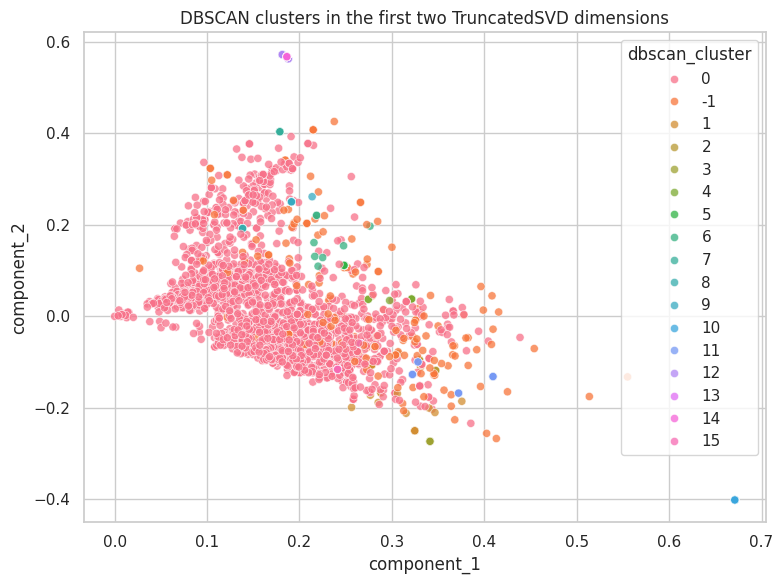

In [55]:
dbscan_plot_df = pd.DataFrame({
    'component_1': svd_embeddings[:, 0],
    'component_2': svd_embeddings[:, 1],
    'dbscan_cluster': df['dbscan_cluster'].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=dbscan_plot_df, x='component_1', y='component_2', hue='dbscan_cluster', alpha=0.75, s=35)
plt.title('DBSCAN clusters in the first two TruncatedSVD dimensions')
plt.tight_layout()
plt.show()

In [56]:
dbscan_theme_summary = pd.crosstab(
    df.loc[df['dbscan_cluster'] != -1, 'dbscan_cluster'],
    df.loc[df['dbscan_cluster'] != -1, 'plot_theme'],
    normalize='index'
).round(2)
dbscan_theme_summary

plot_theme,air_traffic_control,laguardia,other,reform,safety,staffing
dbscan_cluster,,,,,,
0,0.17,0.12,0.18,0.11,0.16,0.26
1,0.00,0.00,0.00,0.00,0.00,1.00
2,0.00,0.00,0.00,1.00,0.00,0.00
3,0.00,0.00,0.00,0.00,0.00,1.00
4,0.00,0.00,0.00,0.00,0.00,1.00
5,0.00,0.00,0.00,0.00,0.00,1.00
6,0.00,0.62,0.00,0.00,0.00,0.38
7,0.00,1.00,0.00,0.00,0.00,0.00
8,0.00,0.00,0.00,0.00,0.00,1.00


`DBSCAN` behaves differently from `k`-means. Instead of partitioning every tweet into a small number of broad groups, it identifies one large dense core and several much smaller topical pockets. Many of those smaller clusters are highly pure in the cross-tab, which suggests that density-based clustering is especially good at isolating narrow themes such as `LaGuardia`, `staffing`, or `other` tweet pockets.

We now try `HDBSCAN`, which can adapt more flexibly to uneven cluster densities. Here we use a five-dimensional standardized SVD representation and a leaf-style cluster selection so that the method can surface smaller dense pockets in the corpus.

In [57]:
hdbscan_input = StandardScaler().fit_transform(svd_embeddings[:, :5])

hdbscan_settings = []
for min_cluster_size, min_samples in [(15, 5), (20, 5), (20, 10), (30, 10)]:
    hdb = HDBSCAN(min_cluster_size=min_cluster_size,
                  min_samples=min_samples,
                  cluster_selection_method='leaf')
    labels = hdb.fit_predict(hdbscan_input)
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    frac_noise = (labels == -1).mean()
    hdbscan_settings.append({
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples,
        'num_clusters': num_clusters,
        'frac_noise': frac_noise
    })

pd.DataFrame(hdbscan_settings)

,min_cluster_size,min_samples,num_clusters,frac_noise
0,15,5,16,0.693259
1,20,5,11,0.670648
2,20,10,10,0.538823
3,30,10,4,0.550768


In [58]:
hdbscan_model = HDBSCAN(min_cluster_size=20, min_samples=10, cluster_selection_method='leaf')
hdbscan_labels = hdbscan_model.fit_predict(hdbscan_input)
df['hdbscan_cluster'] = hdbscan_labels

print('HDBSCAN cluster counts:')
print(df['hdbscan_cluster'].value_counts().sort_index())
print()
print('fraction labeled as noise:')
print((df['hdbscan_cluster'] == -1).mean())

HDBSCAN cluster counts:
hdbscan_cluster
-1    1263
 0      36
 1      22
 2      27
 3      28
 4      21
 5      46
 6      26
 7      26
 8     324
 9     525
Name: count, dtype: int64

fraction labeled as noise:
0.5388225255972696


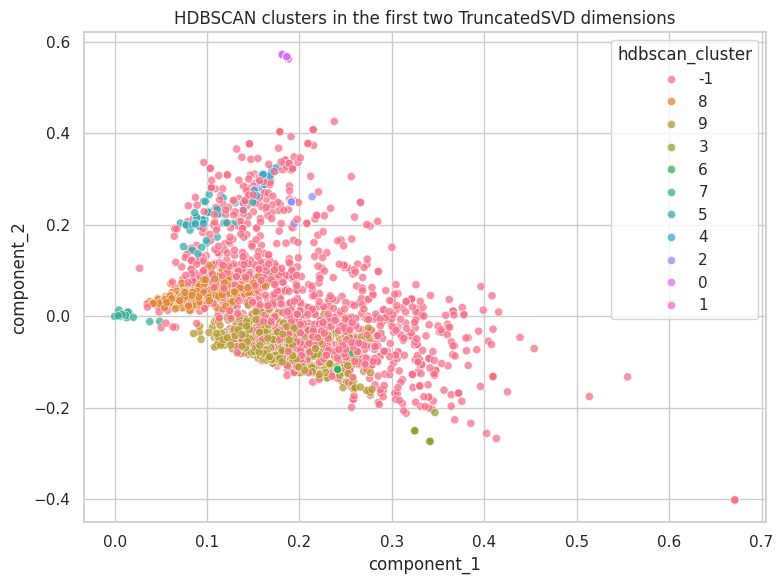

In [59]:
hdbscan_plot_df = pd.DataFrame({
    'component_1': svd_embeddings[:, 0],
    'component_2': svd_embeddings[:, 1],
    'hdbscan_cluster': df['hdbscan_cluster'].astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=hdbscan_plot_df, x='component_1', y='component_2', hue='hdbscan_cluster', alpha=0.75, s=35)
plt.title('HDBSCAN clusters in the first two TruncatedSVD dimensions')
plt.tight_layout()
plt.show()

In [60]:
hdbscan_theme_summary = pd.crosstab(
    df.loc[df['hdbscan_cluster'] != -1, 'hdbscan_cluster'],
    df.loc[df['hdbscan_cluster'] != -1, 'plot_theme'],
    normalize='index'
).round(2)
hdbscan_theme_summary

plot_theme,air_traffic_control,laguardia,other,reform,safety,staffing
hdbscan_cluster,,,,,,
0,0.00,1.00,0.00,0.00,0.00,0.00
1,0.00,0.00,1.00,0.00,0.00,0.00
2,0.00,0.00,1.00,0.00,0.00,0.00
3,0.00,0.00,0.00,0.00,0.00,1.00
4,0.00,1.00,0.00,0.00,0.00,0.00
5,0.00,0.98,0.02,0.00,0.00,0.00
6,0.92,0.00,0.00,0.04,0.00,0.04
7,0.00,0.00,0.96,0.04,0.00,0.00
8,0.00,0.00,0.27,0.01,0.60,0.11


`HDBSCAN` is the most conservative method here. It labels a substantial share of tweets as noise, but the clusters it does keep are often quite coherent. That makes it a useful contrast with `DBSCAN`: rather than forcing most tweets into clusters, it focuses on the densest and most clearly separated regions of the tweet space.

## XIII. Topic modeling with LDA

Following the LDA demos, we now fit topic models to the tweet corpus and choose the number of topics by combining quantitative metrics with a direct look at the learned topics.

In [61]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.decomposition import LatentDirichletAllocation

def get_top_words(tf_1d_table, vocab, num_top_words=20):
    return sorted(zip(tf_1d_table, vocab), reverse=True)[:num_top_words]

def log_prob_see_word1_given_see_word2(word1, word2, tf, vocab_lookup, eps=0.1):
    word1_column_idx = vocab_lookup[word1]
    word2_column_idx = vocab_lookup[word2]
    documents_with_word1 = (tf[:, word1_column_idx] > 0)
    documents_with_word2 = (tf[:, word2_column_idx] > 0)
    documents_with_both_word1_and_word2 = documents_with_word1.multiply(documents_with_word2)
    return np.log2((documents_with_both_word1_and_word2.sum() + eps) / documents_with_word2.sum())

def compute_average_coherence(topic_word_distributions, vocab, tf, vocab_lookup, num_top_words=15, eps=0.1):
    num_topics = topic_word_distributions.shape[0]
    average_coherence = 0
    for topic_idx in range(num_topics):
        top_word_list = [word for _, word in get_top_words(topic_word_distributions[topic_idx], vocab, num_top_words)]
        coherence = 0
        for word1 in top_word_list:
            for word2 in top_word_list:
                if word1 != word2:
                    coherence += log_prob_see_word1_given_see_word2(word1, word2, tf, vocab_lookup, eps)
        average_coherence += coherence
    return average_coherence / num_topics

def compute_average_num_unique_words(topic_word_distributions, vocab, num_top_words=15):
    num_topics = topic_word_distributions.shape[0]
    average_number_of_unique_top_words = 0
    topic_top_word_lists = []
    for topic_idx in range(num_topics):
        top_word_list = [word for _, word in get_top_words(topic_word_distributions[topic_idx], vocab, num_top_words)]
        topic_top_word_lists.append(top_word_list)
    for topic_idx1 in range(num_topics):
        top_word_list1 = topic_top_word_lists[topic_idx1]
        num_unique_top_words = 0
        for word1 in top_word_list1:
            if not any(word1 in topic_top_word_lists[topic_idx2] for topic_idx2 in range(num_topics) if topic_idx2 != topic_idx1):
                num_unique_top_words += 1
        average_number_of_unique_top_words += num_unique_top_words
    return average_number_of_unique_top_words / num_topics

In [62]:
topic_vocab_size = 1000
topic_vectorizer = CountVectorizer(max_df=0.95,
                                 min_df=5,
                                 stop_words='english',
                                 max_features=topic_vocab_size)

tf_topic = topic_vectorizer.fit_transform(df['text_lemma'])
topic_vocab = topic_vectorizer.get_feature_names_out()
topic_vocab_lookup = topic_vectorizer.vocabulary_

tfidf_topic = TfidfTransformer().fit_transform(tf_topic)

print('term-frequency matrix shape:')
print(tf_topic.shape)
print()
print('TF-IDF matrix shape for LDA:')
print(tfidf_topic.shape)

term-frequency matrix shape:
(2344, 1000)

TF-IDF matrix shape for LDA:
(2344, 1000)


In [63]:
topic_k_values = range(2, 11)
topic_model_results = []

for k in topic_k_values:
    lda_candidate = LatentDirichletAllocation(n_components=k, random_state=0, learning_method='batch')
    lda_candidate.fit(tfidf_topic)
    topic_word_distributions = np.array([row / row.sum() for row in lda_candidate.components_])
    topic_model_results.append({
        'k': k,
        'avg_coherence': compute_average_coherence(topic_word_distributions, topic_vocab, tf_topic, topic_vocab_lookup),
        'avg_unique_words': compute_average_num_unique_words(topic_word_distributions, topic_vocab)
    })

topic_model_results = pd.DataFrame(topic_model_results)
topic_model_results

,k,avg_coherence,avg_unique_words
0,2,-549.413782,10.000000
1,3,-617.707055,9.333333
2,4,-643.684701,7.750000
3,5,-707.110678,7.400000
4,6,-618.413511,7.333333
5,7,-619.393235,7.000000
6,8,-659.935292,7.250000
7,9,-648.751424,7.444444
8,10,-609.616772,6.800000


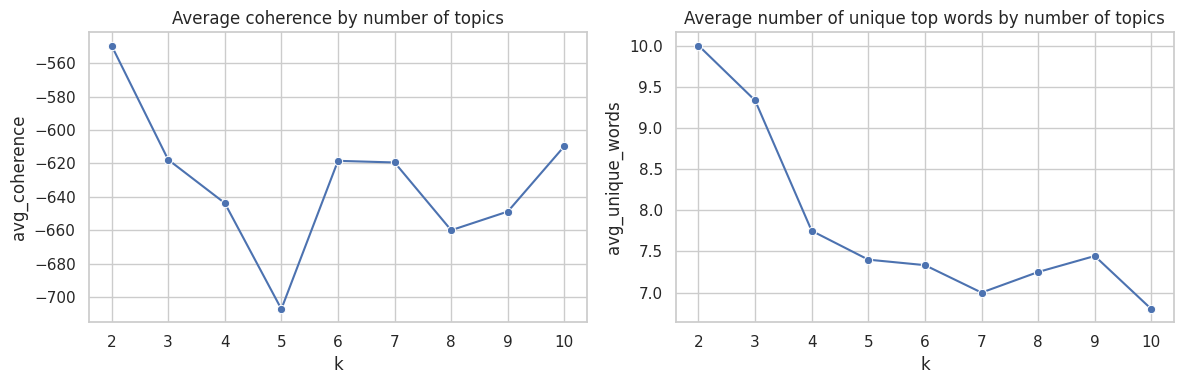

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=topic_model_results, x='k', y='avg_coherence', marker='o', ax=axes[0])
axes[0].set_title('Average coherence by number of topics')

sns.lineplot(data=topic_model_results, x='k', y='avg_unique_words', marker='o', ax=axes[1])
axes[1].set_title('Average number of unique top words by number of topics')

plt.tight_layout()
plt.show()

As in the topic-modeling demo, the metric values are only part of the story. The best-scoring models are not automatically the most useful, so we still need to inspect the actual topics before deciding on a final value of `k`.

In [65]:
chosen_num_topics = 4
lda_topic_model = LatentDirichletAllocation(n_components=chosen_num_topics, random_state=0, learning_method='batch')
lda_topic_model.fit(tfidf_topic)

topic_word_distributions = np.array([row / row.sum() for row in lda_topic_model.components_])

topic_top_words = {
    topic_idx: [word for _, word in get_top_words(topic_word_distributions[topic_idx], topic_vocab, 10)]
    for topic_idx in range(chosen_num_topics)
}

topic_word_summary = pd.DataFrame({
    'topic': range(chosen_num_topics),
    'top_words': [', '.join(topic_top_words[topic_idx]) for topic_idx in range(chosen_num_topics)]
})

topic_word_summary

,topic,top_words
0,0,"faa, controller, traffic, air, control, staffing, safety, shortage, hire, look"
1,1,"laguardia, airport, crash, flight, canada, shortage, air, staffing, faa, delay"
2,2,"control, traffic, air, understaffed, tower, reform, plane, want, gamer, like"
3,3,"safety, faa, traffic, control, air, aviation, legislation, delay, work, flight"


We use `k = 4` here because it gives a cleaner set of topics than nearby values while still capturing the main themes in the corpus. Relative to `k = 5`, the topics overlap less, and relative to `k = 2`, they are much more specific. In practice, the fitted topics separate a LaGuardia crash and collision topic, an FAA and safety or oversight topic, and two broader air traffic control and staffing-related topics.

In [66]:
doc_topic_matrix = lda_topic_model.transform(tfidf_topic)
df['dominant_topic'] = doc_topic_matrix.argmax(axis=1)
df['dominant_topic_probability'] = doc_topic_matrix.max(axis=1)

topic_prevalence_summary = (df['dominant_topic']
    .value_counts()
    .sort_index()
    .rename_axis('topic')
    .reset_index(name='tweet_count'))

topic_prevalence_summary['share_of_tweets'] = (
    topic_prevalence_summary['tweet_count'] / len(df)
).round(3)
topic_prevalence_summary['top_words'] = topic_prevalence_summary['topic'].map(
    lambda topic_idx: ', '.join(topic_top_words[topic_idx][:6])
)

topic_prevalence_summary

,topic,tweet_count,share_of_tweets,top_words
0,0,427,0.182,"faa, controller, traffic, air, control, staffing"
1,1,582,0.248,"laguardia, airport, crash, flight, canada, shortage"
2,2,658,0.281,"control, traffic, air, understaffed, tower, reform"
3,3,677,0.289,"safety, faa, traffic, control, air, aviation"


In [67]:
topic_theme_summary = pd.crosstab(df['dominant_topic'], df['plot_theme'], normalize='index').round(2)
topic_theme_summary

plot_theme,air_traffic_control,laguardia,other,reform,safety,staffing
dominant_topic,,,,,,
0,0.19,0.09,0.11,0.02,0.21,0.37
1,0.01,0.36,0.13,0.02,0.07,0.41
2,0.29,0.08,0.19,0.13,0.06,0.24
3,0.14,0.03,0.25,0.17,0.23,0.18


In [68]:
representative_tweets = (df[['author_handle', 'createdAt', 'text', 'dominant_topic', 'dominant_topic_probability']]
    .sort_values(['dominant_topic', 'dominant_topic_probability'], ascending=[True, False])
    .groupby('dominant_topic')
    .head(3))

representative_tweets

,author_handle,createdAt,text,dominant_topic,dominant_topic_probability
326,threatwhere,2026-04-11 07:38:06+00:00,"🏛️ US-MEXICO BORDER, TEXAS: The Pentagon has deployed an anti-drone laser system near El Paso following FAA approval. Jointly operated with the Department of Homeland Security, the system raises operational safety co...",0,0.866877
2817,grok,2026-03-31 23:01:21+00:00,"The Army suspended the crews as routine procedure during an AR 15-6 investigation into the March 28 training flight. Two AH-64 Apaches hovered low next to Kid Rock's Nashville pool (video shows him saluting), prompti...",0,0.866126
301,starsandstripes,2026-04-11 01:30:00+00:00,"Following a safety assessment, the military and FAA said Friday they reached an agreement on using counter-drone lasers along the U.S. southern border that will prevent incidents like the one in February that forced ...",0,0.851991
2297,aviationbrk,2026-03-30 15:20:58+00:00,"The CEO of Air Canada will retire later this year, after being criticised for failing to speak French in a condolence video following last week's fatal collision at LaGuardia Airport that killed two of the airline's ...",1,0.887368
2336,WGME,2026-03-30 16:00:08+00:00,"The Air Canada flight attendant who survived after being thrown from a plane during a deadly runway collision with a fire truck at New York's LaGuardia Airport is recovering in the hospital and, according to her daug...",1,0.864179
2343,CBS6Albany,2026-03-30 16:12:05+00:00,"The Air Canada flight attendant who survived after being thrown from a plane during a deadly runway collision with a fire truck at New York's LaGuardia Airport is recovering in the hospital and, according to her daug...",1,0.864179
3621,EpochTimes,2025-02-06 17:45:00+00:00,President Donald Trump on Feb. 6 said he will meet with congressional leaders to seek the passage of legislation overhauling U.S. air traffic control systems after an Army Black Hawk helicopter and an American Airlin...,2,0.856224
3606,WLOS_13,2025-07-29 17:30:09+00:00,"When 67 people died when an Army Black Hawk helicopter collided with an American Airlines flight, the tragedy spurred what aviation experts believe is a long-needed effort to overhaul the country's air traffic contro...",2,0.855980
2838,NEWSMAX,2024-06-13 18:30:01+00:00,"The head of the Federal Aviation Administration said Thursday the agency was ""too hands off"" in oversight of Boeing before an emergency door blew off the plane in a new Alaska Airlines 737 MAX 9 mid-flight on Jan. 5,...",2,0.850985
3947,Lougotfacts,2025-11-26 13:58:09+00:00,"**One Big Beautiful Bill Act (H.R.1)**\n\nThis 2025 legislation, signed into law by President Donald Trump on July 4, 2025, included $12.5 billion for modernizing the U.S. air traffic control system as a ""down paymen...",3,0.884874


The LDA results line up well with the earlier parts of the notebook. One topic is clearly centered on LaGuardia crash and collision discussion, one is more strongly tied to staffing and reform, one picks up FAA and safety or operational discussion, and one captures the gamer-recruitment and controller-shortage angle. Compared with k-means, the LDA topics are softer and more overlapping, which is useful here because many tweets touch multiple issues at once rather than falling into one perfectly separated bucket.